# Ligand Perturbation

This notebook walks through simulating the overexpression of the IL21 ligand and
studying the shift in cell profile across T cells in human tonsils

In [1]:
%config InlineBackend.figure_format = 'retina'

In [2]:
import pandas as pd
import scanpy as sc
import sys 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sys.path.append('/Users/koush/Projects/SpaceOracle/src')

In [3]:
from SpaceTravLR.virtual_tissue import VirtualTissue

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [4]:
adata = sc.read_h5ad('/Volumes/SSD/training_data/snrna_human_tonsil.h5ad')
adata

AnnData object with n_obs × n_vars = 5778 × 3333
    obs: 'cell_type', 'author_cell_type', 'cell_type_int', 'banksy_celltypes', 'cell_type_2'
    uns: 'cell_thresholds', 'cell_type_int_colors', 'received_ligands', 'received_ligands_tfl'
    obsm: 'spatial', 'spatial_unscaled'
    layers: 'imputed_count', 'normalized_count'

### Define color palette

In [5]:
color_dict = {
    'Naive CD4 T': '#f721b7',
    'Treg': '#ecc91d',
    'T memory': '#3a9c2b',
    'Th1': '#c43cf2',
    'Th2': '#5e6ff3',
    'T_CD8': '#dd3652',
    'T_follicular_helper': '#e28723',
}

### Setup a VirtualTissue for loading and visualizing perturbations

In [6]:
tonsil = VirtualTissue(
    adata = adata,
    annot = 'cell_type_2',
    betadatas_path = '/Volumes/SSD/lasso_runs/human_tonsil',
    ko_path = '/Volumes/SSD/genome_screens/human_tonsil',
    color_dict=color_dict
)

In [17]:
tonsil.init_cartography(adata, 
    restrict_to=[
        'Naive CD4 T',
        'T_follicular_helper', 
        'Th2', 
        'Th1', 
        'Treg',
        'T_CD8',
        'T memory'
    ]
)


plot_params = {
    'perturb_target': '',
    'hue': 'cell_type_2',
    'curve': True,
    'grid_scale': 2, 
    'alpha': 0.6,
    'grains': 25,
    'figsize': (5, 5),
    'dpi': 200,
    'legend_fontsize': 7,
    'dynamic_alpha': False,
    'scatter_size': 25,
    'rename': {
        'T_follicular_helper': 'Tfh',
        'T_CD8': 'CD8 T',
        'T_CD4': 'non-Tfh CD4 T',
        'B_germinal_center': 'B Germinal Center',
        'B_naive': 'B Naive',
        'B_memory': 'B Memory',
        'Naive CD4 T': 'Th0',
    },
    'limit_clusters': True,
    'highlight_clusters': [
        'T_follicular_helper',
        'Th1', 
        'Th2',
        'Naive CD4 T',
        'Treg',
        'T memory'

    ]
}

### The simulation results are visualized as a vector map on the UMAP space, representing a potential shift in cell transcriptomic identity in response to IL21 perturbation.  

In [10]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)

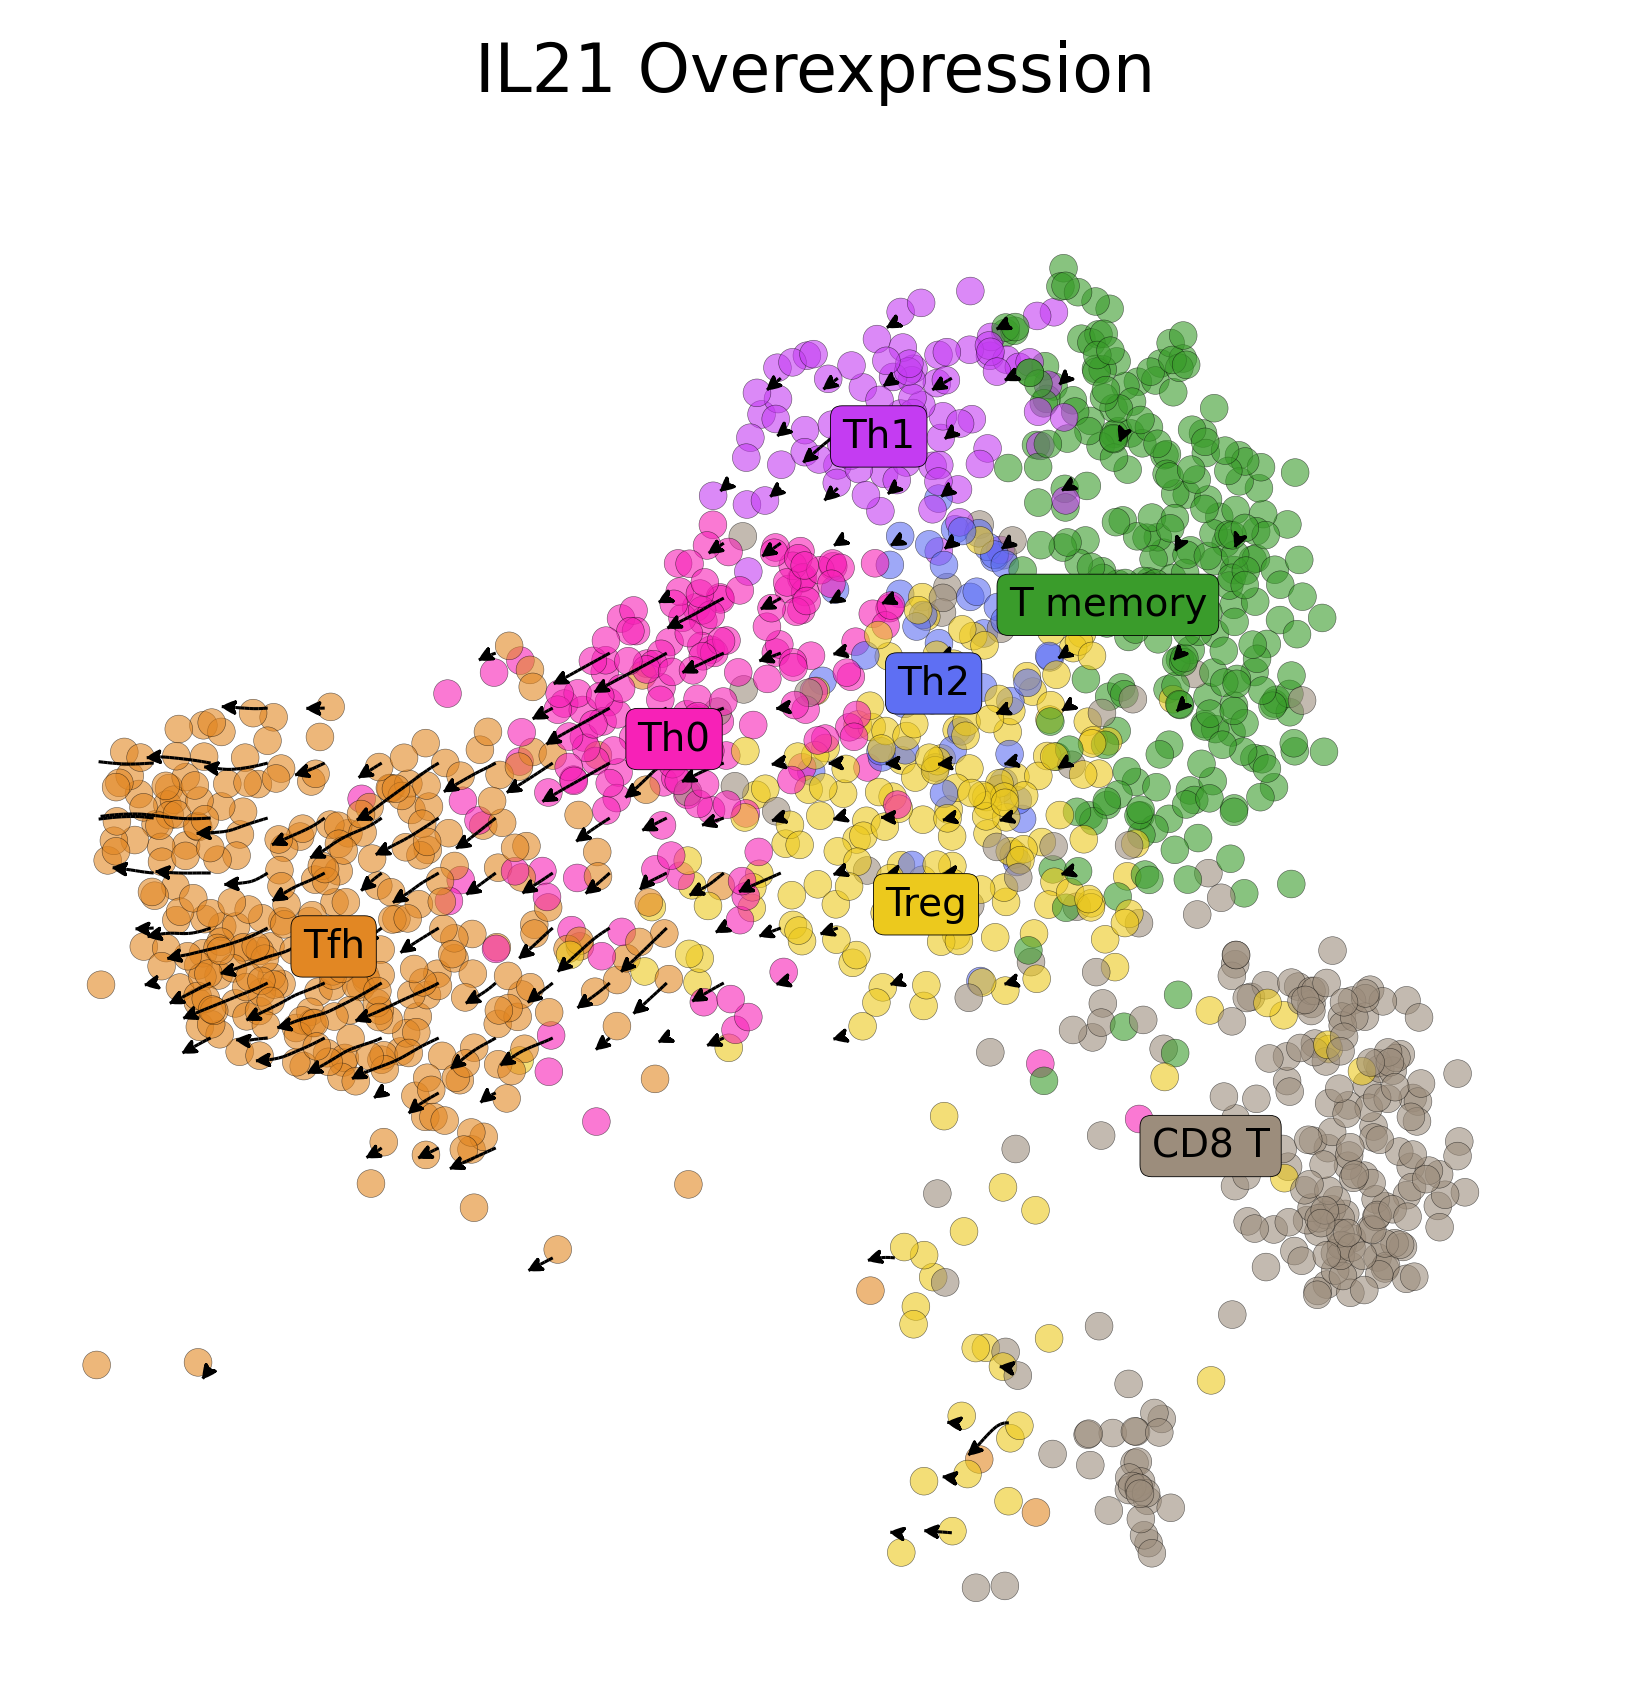

In [ ]:
plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'

perturbed_df = pd.read_parquet(
    '/Volumes/SSD/genome_screens/human_tonsil/IL21_4n_maxx.parquet')

grid_points, vector_field = tonsil.plot_arrows(
    perturbed_df=perturbed_df,
    **plot_params
)

plt.title('IL21 Overexpression')
plt.show()

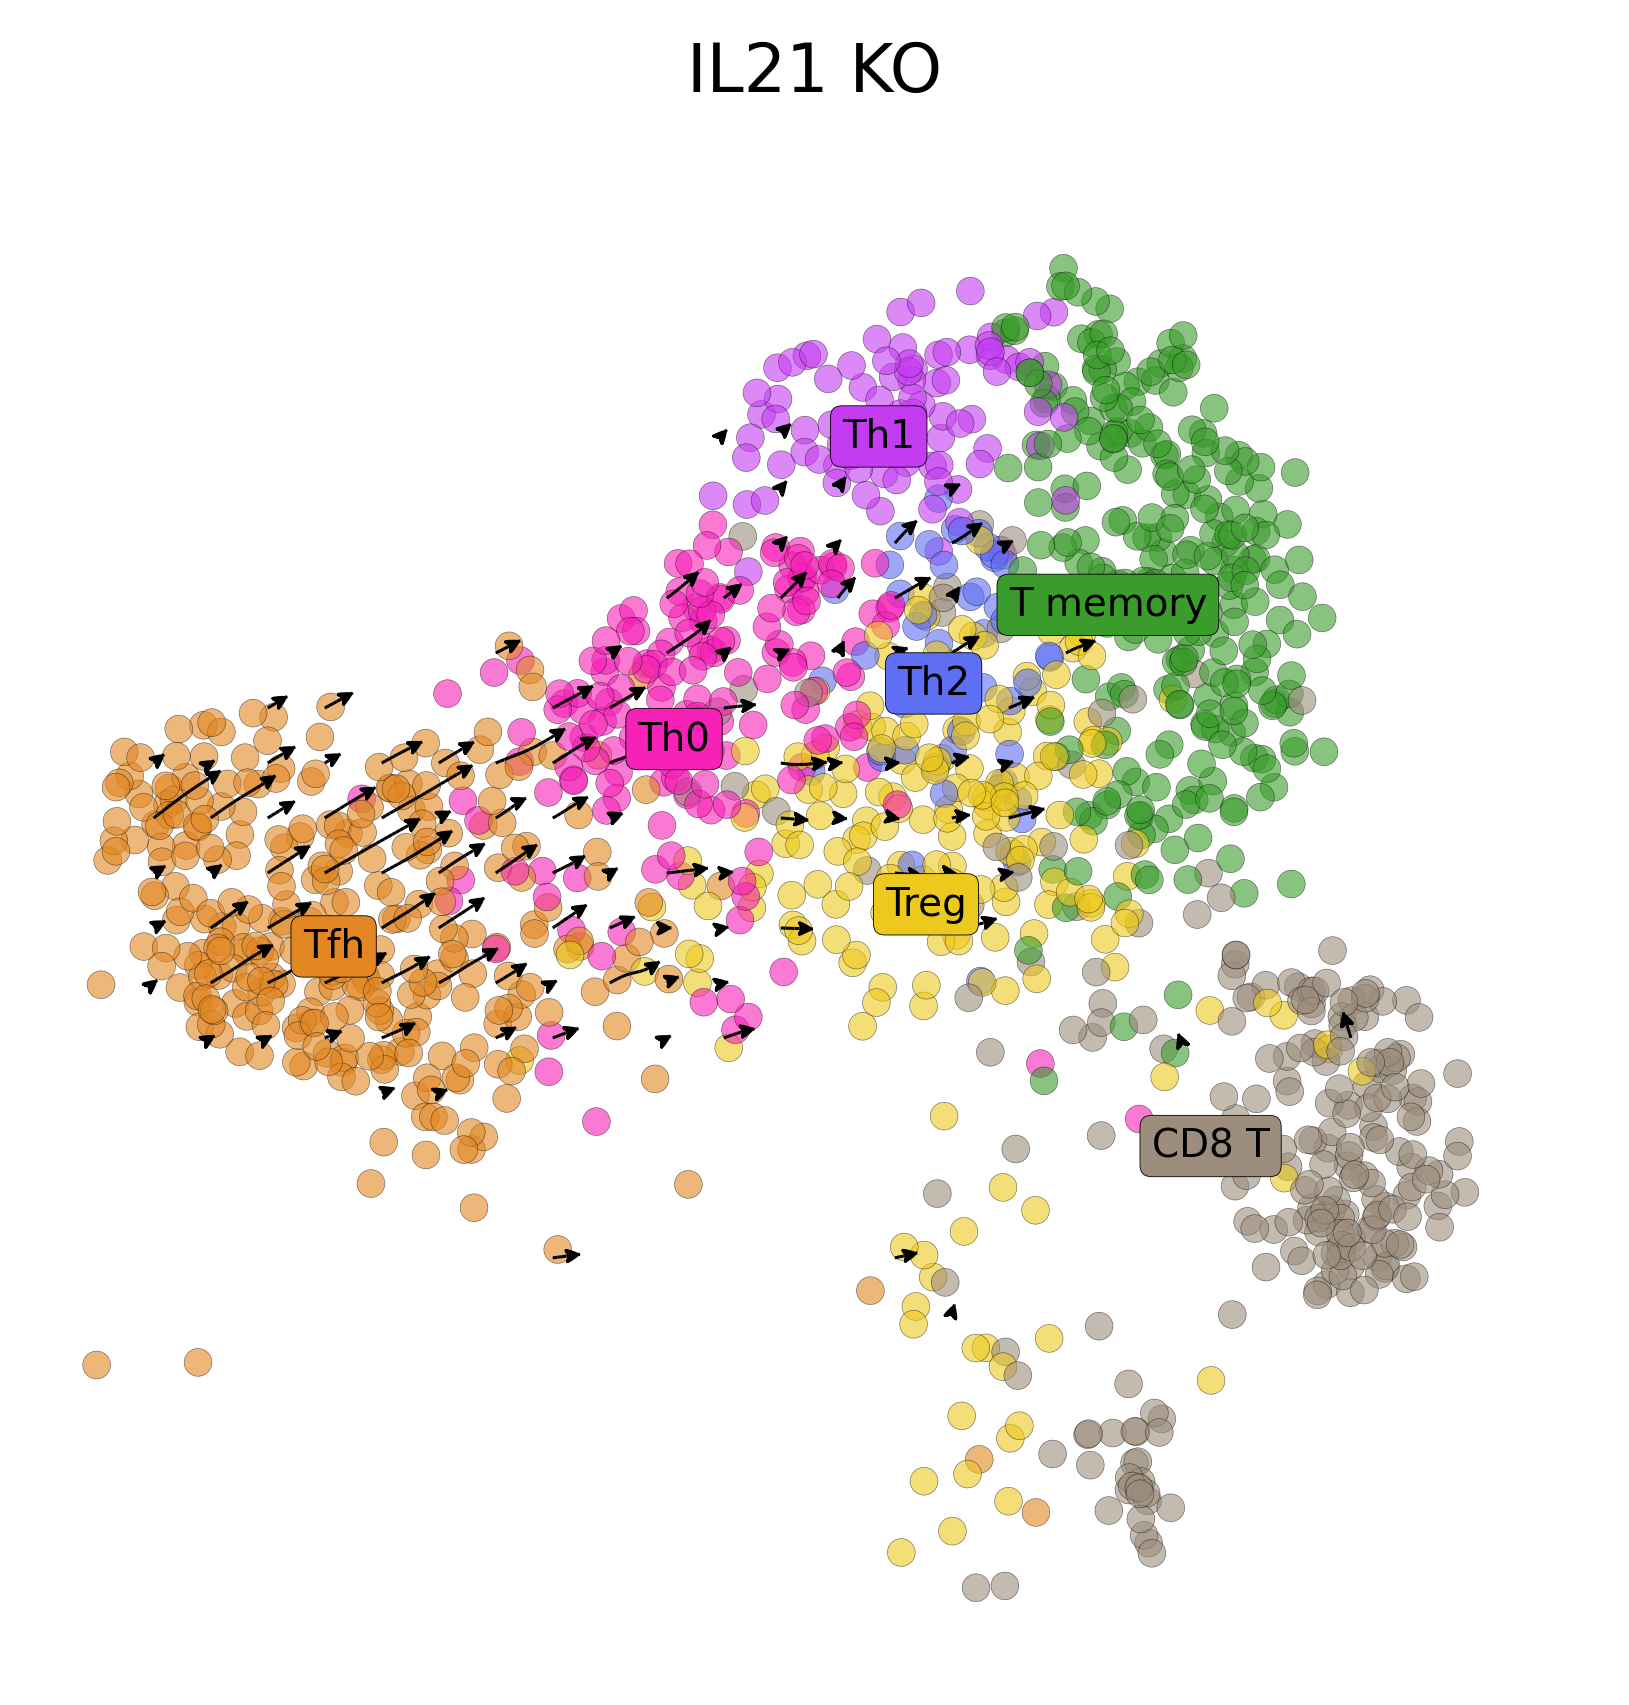

In [ ]:
perturbed_df = pd.read_parquet(
    '/Volumes/SSD/genome_screens/human_tonsil/IL21_4n_0x.parquet')

grid_points, vector_field = tonsil.plot_arrows(
    perturbed_df=perturbed_df,
    **plot_params
)

plt.title('IL21 KO')
plt.show()